In [1]:
%matplotlib widget

C:\Users\Athar\AppData\Local\Temp\ipykernel_26192\1231676595.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  tan_val = 2 * np.cos(theta1) / np.tan(theta2)
C:\Users\Athar\AppData\Local\Temp\ipykernel_26192\1231676595.py:21: RuntimeWarning: divide by zero encountered in scalar divide
  c = (b / np.sin(theta1)) * np.sqrt(np.tan(theta2)**2 + 4 * np.cos(theta1)**2)


Calculated Derived Parameter c: 10.00 m
Initial State Vector [x, y, z]: [6.00, 0.00, 10.00] m


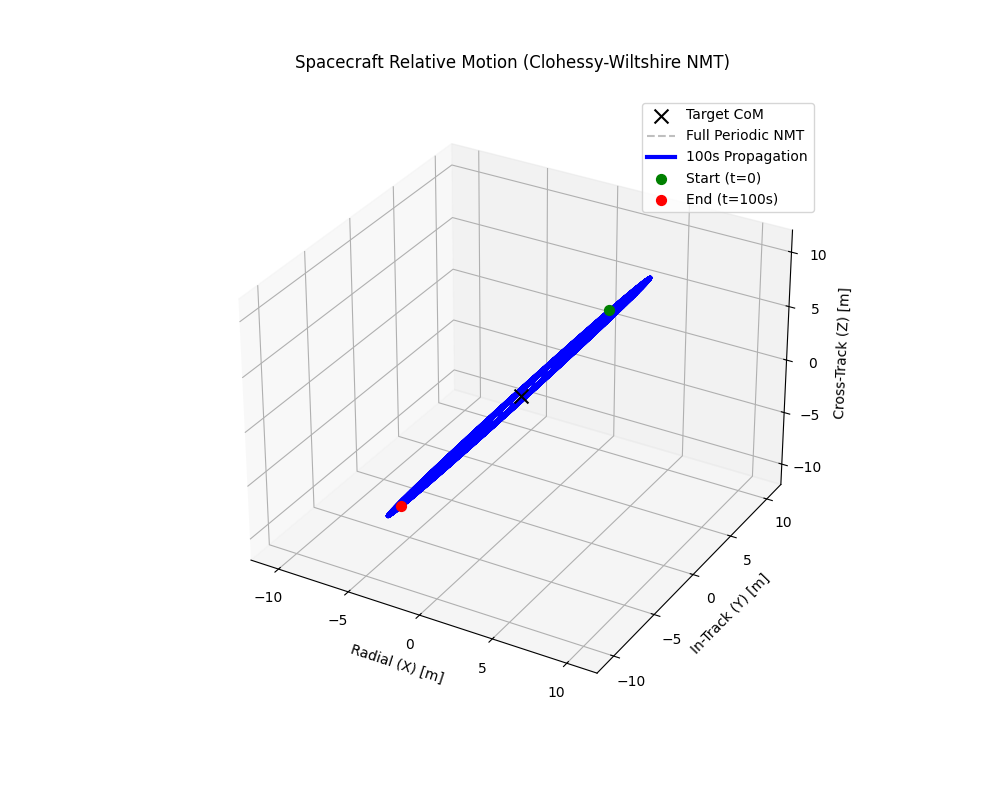

In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from numpy import cos, sin

a = 800000 # Semi-major axis of chief satellite [m]
mu = 398600.4418 * pow(10, 14)
n = np.sqrt(mu/(a**3)) # Mean motion 
#print(n2)
#n = 0.0011 # Mean motion 
period = 2 * np.pi / n # Period
b = 6.0 # Scale factor of max y distance which is 2b
theta1 = np.radians(0.0)  # Out-of-plane angle 1 [rad]
theta2 = np.radians(0.0)  # Out-of-plane angle 2 [rad]
nu = np.radians(90) # Initial phase angle: 0 is at Y


tan_val = 2 * np.cos(theta1) / np.tan(theta2)
psi = nu - np.arctan(tan_val)

c = (b / np.sin(theta1)) * np.sqrt(np.tan(theta2)**2 + 4 * np.cos(theta1)**2)
c = 10
#X_0 = [x, y, z, x_dot, y_dot, z_dot]
X_0 = np.array([
    b * np.sin(nu),
    2 * b * np.cos(nu),
    c * np.sin(nu - psi),
    b * n * np.cos(nu),
    -2 * b * n * np.sin(nu),
    c * n * np.cos(nu - psi)
])

print(f"Calculated Derived Parameter c: {c:.2f} m")
print(f"Initial State Vector [x, y, z]: [{X_0[0]:.2f}, {X_0[1]:.2f}, {X_0[2]:.2f}] m")

A_c = np.array([
    [0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 1],
    [3 * n**2, 0, 0, 0, 2 * n, 0],
    [0, 0, 0, -2 * n, 0, 0],
    [0, 0, -n**2, 0, 0, 0]
])

def cw_equations(t, state):
    return A_c @ state

# Propagate for the requested 100 seconds
t_span_100s = (0, 100)
t_eval_100s = np.linspace(0, 100, 500)
sol_100s = solve_ivp(cw_equations, t_span_100s, X_0, t_eval=t_eval_100s, rtol=1e-8, atol=1e-10)

# Propagate for a full orbital period to show the complete ellipse
t_span_full = (0, period)
t_eval_full = np.linspace(0, period, 2000)
sol_full = solve_ivp(cw_equations, t_span_full, X_0, t_eval=t_eval_full, rtol=1e-8, atol=1e-10)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot Target 
ax.scatter(0, 0, 0, color='black', s=100, marker='x', label='Target CoM')

# Plot Full Elliptical NMT 
ax.plot(sol_full.y[0], sol_full.y[1], sol_full.y[2], 
        color='gray', linestyle='--', alpha=0.5, label='Full Periodic NMT')

# Plot the 100-second propagated trajectory (Solid)
ax.plot(sol_100s.y[0], sol_100s.y[1], sol_100s.y[2], 
        color='blue', linewidth=3, label='100s Propagation')

# Mark start and end of the 100s burn
ax.scatter(sol_100s.y[0, 0], sol_100s.y[1, 0], sol_100s.y[2, 0], color='green', s=50, label='Start (t=0)')
ax.scatter(sol_100s.y[0, -1], sol_100s.y[1, -1], sol_100s.y[2, -1], color='red', s=50, label='End (t=100s)')

ax.set_title('Spacecraft Relative Motion (Clohessy-Wiltshire NMT)', pad=20)
ax.set_xlabel('Radial (X) [m]')
ax.set_ylabel('In-Track (Y) [m]')
ax.set_zlabel('Cross-Track (Z) [m]')

# Make axes equal for accurate geometric representation
max_val = np.max(np.abs(sol_full.y[0:3]))
ax.set_xlim(-max_val, max_val)
ax.set_ylim(-max_val, max_val)
ax.set_zlim(-max_val, max_val)

ax.legend()
plt.show()

In [9]:
def cart2rel(n, t):
    Gamma = np.array([[1, 0, -cos(n*t), -sin(n*t), 0, 0],
                      [0, 1, 2*sin(n*t), -2*cos(n*t), 0, 0],
                      [0, 0, 0, 0, sin(n*t), cos(n*t)],
                      [0, 0, n*sin(n*t), -n*cos(n*t), 0, 0],
                      [-3*n/2, 0, 2*n*cos(n*t), 2*n*sin(n*t), 0, 0],
                      [0, 0, 0, 0, n*cos(n*t), n*sin(n*t)]])
    return Gamma

In [ ]:
## Define Orbit in terms of Rel Orb Parameters
H_t = np.array([0.4282, 0.2854, 1.4272]) * 1e5 # Defined Somewhat Arbitrarily for Example

a_t = a # Semimajor axis of Target
a_c = a_t # Semimjaor axis of Chaser - same as target for now
et = 0.1
e_c = 0.1

num_steps = len(sol_full.t)

# Initialize a (6, N) array to hold the ROE time history
# Rows correspond to [da, dlambda, dex, dey, dix, diy]
da_history = np.zeros((6, num_steps))

# Loop through each time step to compute the ROEs
for i in range(num_steps):
    t_i = sol_full.t[i]
    
    # Extract the 6x1 Cartesian state [x, y, z, x_dot, y_dot, z_dot]^T at time t_i
    cartesian_state = sol_full.y[:, i]
    
    # Get the Gamma matrix for this specific time
    Gamma_i = cart2rel(n, t_i)
    
    # Invert Gamma, multiply by the Cartesian state, and divide by semi-major axis 'a'
    Gamma_inv = np.linalg.inv(Gamma_i) #!! Check to make sure this is numerically stable enough
    da_history[:, i] = (Gamma_inv @ cartesian_state) / a



In [ ]:
## Analyze results of rel orbit parameters after converting from rel_cartesian parameters

b = 6.0              
theta1 = np.radians(45.0)  
theta2 = np.radians(45.0)  
nu = np.radians(0.0)       

tan_val = 2 * np.cos(theta1) / np.tan(theta2)
psi = nu - np.arctan(tan_val)
c = (b / np.sin(theta1)) * np.sqrt(np.tan(theta2)**2 + 4 * np.cos(theta1)**2)

# Chaser Initial State [x, y, z, vx, vy, vz]
cw_initial = np.array([
    b * np.sin(nu),
    2 * b * np.cos(nu),
    c * np.sin(nu - psi),
    b * n * np.cos(nu),
    -2 * b * n * np.sin(nu),
    c * n * np.cos(nu - psi)
])

[-6.0000000e+00 -3.6739404e-16]


In [22]:
import plotly.graph_objects as go
import numpy as np

# Create the figure
fig = go.Figure()

# 1. Plot Target CoM
fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers',
    marker=dict(size=6, color='black', symbol='cross'),
    name='Target CoM'
))

# 2. Plot Full Elliptical NMT (Dashed)
fig.add_trace(go.Scatter3d(
    x=sol_full.y[0], y=sol_full.y[1], z=sol_full.y[2],
    mode='lines',
    line=dict(color='gray', width=3, dash='dash'),
    opacity=0.5,
    name='Full Periodic NMT'
))

# 3. Plot the 100-second propagated trajectory (Solid)
fig.add_trace(go.Scatter3d(
    x=sol_100s.y[0], y=sol_100s.y[1], z=sol_100s.y[2],
    mode='lines',
    line=dict(color='blue', width=6),
    name='100s Propagation'
))

# 4. Mark start and end of the 100s burn
fig.add_trace(go.Scatter3d(
    x=[sol_100s.y[0, 0]], y=[sol_100s.y[1, 0]], z=[sol_100s.y[2, 0]],
    mode='markers',
    marker=dict(size=6, color='green'),
    name='Start (t=0)'
))

fig.add_trace(go.Scatter3d(
    x=[sol_100s.y[0, -1]], y=[sol_100s.y[1, -1]], z=[sol_100s.y[2, -1]],
    mode='markers',
    marker=dict(size=6, color='red'),
    name='End (t=100s)'
))

# Formatting the Layout
fig.update_layout(
    title='Spacecraft Relative Motion (Clohessy-Wiltshire NMT)',
    scene=dict(
        xaxis_title='Radial (X) [m]',
        yaxis_title='In-Track (Y) [m]',
        zaxis_title='Cross-Track (Z) [m]',
        # aspectmode='data' enforces perfectly equal axis scaling automatically!
        aspectmode='data' 
    ),
    width=900,
    height=800,
    legend=dict(x=0.8, y=0.9)
)

# Display the interactive plot
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [19]:
def get_T_inv(t, n):
    '''
    Converts between Cartesian coordinates and Relative orbit dynamics.
    In literature referenced for this project, it is the T' matrix
    - x: Initial position of chaser
    - v: Initial velocity of chaser
    - a: Semi-major axis of chief
    - n: Mean Motion of chief
    '''
    inv_T = np.array([[4, 0, 0, 0, 2/n, 0], 
                      [0, 1, 0, -2/n, 0, 0], 
                      [3*np.cos(n*t), 0, 0, np.sin(n*t)/n, 2*np.cos(n*t)/n, 0],
                      [3*np.sin(n*t), 0, 0, -np.cos(n*t)/n, 2*np.sin(n*t)/n, 0],
                      [0, 0, np.sin(n*t), 0, 0, np.cos(n*t)/n],
                      [0, 0, -np.cos(n*t), 0, 0, np.sin(n*t)]])
    
    return inv_T
u = 0
A = np.array([[0, 0, 0, 0, 0, 0],
              [ -3/2 * n, 0, 0, 0, 0, 0],
              [0, 0, 0, 0, 0, 0],
              [0, 0, 0, 0, 0, 0],
              [0, 0, 0, 0, 0, 0],
              [0, 0, 0, 0, 0, 0]])
B = np.array([[0, 2, 0],
              [-2, 0, 0],
              [np.sin(u), 2*np.cos(u), 0], 
              [-np.cos(u), 2*np.sin(u), 0], 
              [0, 0, np.cos(u)],
              [0, 0, np.sin(u)]])

rho0 = get_T_inv(0, n) @ X_0

print("Initial Scaled ROE State [m]:")
print(f"a*da      = {rho0[0]:.2f} m")
print(f"a*dlambda = {rho0[1]:.2f} m")
print(f"a*de_x    = {rho0[2]:.2f} m")
print(f"a*de_y    = {rho0[3]:.2f} m")
print(f"a*di_x    = {rho0[4]:.2f} m")
print(f"a*di_y    = {rho0[5]:.2f} m")

Initial Scaled ROE State [m]:
a*da      = 0.00 m
a*dlambda = -0.00 m
a*de_x    = -6.00 m
a*de_y    = -0.00 m
a*di_x    = 5.77 m
a*di_y    = -8.16 m
